# Ingeniería de características para HAR con CPC–xLSTM
## Proyecto Integrador — Avance 2

**Equipo 1**  
Isaura Yutsil Flores Escamilla — A01796552  
Paola Alejandra León Guarneros — A01796230  
Dylan Ulises Quiroz Hernández — A01796578  

**Fecha:** 9 de octubre de 2026

> Este notebook contiene código reproducible y narrativa técnica para la fase de preparación de datos de CRISP-ML. Las celdas se entregan sin ejecutar. El objetivo es construir características para reconocer siete actividades humanas (`N`, `LF`, `K`, `PT`, `LT`, `W`, `PF`) y dejar una interfaz compatible con el pipeline CPC–xLSTM de `02_Pipeline_CPC_xLSTM.ipynb`.

## Resumen de decisiones derivadas del Avance 1

El EDA de `Avance1.Equipo1.ipynb` establece el contrato de esta fase: 14 sujetos, ocho canales sEMG, frecuencias efectivas heterogéneas (aprox. 366.66–1005.65 Hz), siete clases, cerca de 67 % del tiempo anotado y una clase neutral que representa alrededor de 43 % del tiempo etiquetado. No se observaron nulos, infinitos, huecos temporales ni canales constantes, pero sí tres ensayos con amplitudes físicamente anómalas, dos archivos con etiquetas inconsistentes y una prueba ausente del sujeto 12.

| Decisión | Implementación en este notebook | Fundamento |
|---|---|---|
| Señal primaria | `Norm_RMS_1..8` | Es una envolvente muscular suavizada y normalizada por MVC; separa reposo de actividad y conserva relación con la carga. |
| Frecuencia común | 50 Hz | `Norm_RMS` ya resume ventanas de 250 ms; 50 Hz conserva su dinámica y produce secuencias de longitud manejable. |
| Ventanas | 4 s; salto de 2 s para CPC y 0.5 s para evaluación | Coincide con el contrato `(B, 8, 200)` del xLSTM y permite comparar con el pipeline existente. |
| Ventanas supervisadas | 100 % etiquetadas y de una sola clase | Evita asignar por el último instante una ventana que cruza transiciones. |
| Transformación | `log1p` + winsorización y `RobustScaler` ajustados sólo en entrenamiento | `%MVC` no está acotado a 100 y tiene cola derecha; la opción robusta reduce la influencia de picos sin borrar la amplitud relativa. |
| Partición | Por sujeto, antes de ajustar transformaciones | Evita fuga entre ventanas solapadas y mide generalización a personas no observadas. |
| Predictores contextuales | Sólo análisis de sensibilidad | Tarea, carga y condición pueden convertirse en atajos; sujeto, archivo y tiempo nunca son predictores. |
| Selección | Filtro de varianza, correlación, información mutua y rama PCA opcional | Reduce redundancia y costo; toda selección se ajusta dentro de cada fold. |

### Correcciones metodológicas respecto al pipeline xLSTM actual

1. El `z-score` calculado con el archivo completo usa información futura para normalizar instantes pasados. Aunque no utiliza la etiqueta, es transductivo y debilita la interpretación causal. Se reemplaza por una transformación ajustada exclusivamente con sujetos de entrenamiento.
2. Elegir hiperparámetros con sujetos 13–14 y reportar el desempeño final sobre esos mismos sujetos produce sesgo de selección. Se propone `train={1..10}`, `validation={11,12}` y `test={13,14}`; alternativamente, validación cruzada anidada por sujeto.
3. La etiqueta del último instante no garantiza que la ventana pertenezca a una sola acción. En la evaluación supervisada se exige pureza y cobertura completas.

## Objetivos y alcance CRISP-ML

Esta fase transforma los hallazgos de comprensión de datos en artefactos reproducibles para modelado. Sus objetivos son:

1. Construir características temporales, espectrales y de coactivación con sentido fisiológico.
2. Codificar variables categóricas sin introducir orden artificial ni fuga de información.
3. definir transformaciones robustas y verificables para la señal secuencial y las características tabulares.
4. Reducir complejidad mediante filtros estadísticos, selección supervisada y una alternativa PCA.
5. Integrar los artefactos de preparación con CPC–xLSTM manteniendo trazabilidad, reproducibilidad y separación estricta por sujeto.

No se fusiona MVNX en esta iteración: el Avance 1 demuestra que los relojes de sEMG y Xsens no están directamente alineados. Incorporarlo sin una alineación por eventos introduciría error de etiqueta. La arquitectura queda preparada para añadir características cinemáticas cuando exista un procedimiento de sincronización validado.

In [1]:
# Configuración reproducible. Esta celda no procesa datos hasta que el usuario la ejecute.
from __future__ import annotations

import re
from dataclasses import dataclass
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import kurtosis, kruskal, normaltest, skew
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectPercentile, VarianceThreshold, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score, make_scorer
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

SEED = 42
rng = np.random.default_rng(SEED)

WORK_DIR = Path.cwd().resolve()
REPO_DIR = WORK_DIR.parent if WORK_DIR.name.lower() == 'notebooks' else WORK_DIR
DATA_ROOT = REPO_DIR / 'datos_unzipped'
EMG_DIR = DATA_ROOT / 'Data'
LABEL_DIR = DATA_ROOT / 'Labels'
CACHE_DIR = REPO_DIR / 'notebooks' / '_cache'

TARGET_FS = 50
WINDOW_SECONDS = 4.0
WINDOW_LEN = int(TARGET_FS * WINDOW_SECONDS)
CPC_HOP = WINDOW_LEN // 2       # 2 s: preentrenamiento autosupervisado
SUPERVISED_HOP = TARGET_FS // 2 # 0.5 s: evaluación con etiquetas
MIN_COVERAGE = 1.0
MIN_PURITY = 1.0

CHANNELS = tuple(range(1, 9))
NORM_RMS_COLS = [f'Norm_RMS_{i}' for i in CHANNELS]
LABEL_ORDER = ['N', 'LF', 'K', 'PT', 'LT', 'W', 'PF']
LABEL_TO_ID = {label: i for i, label in enumerate(LABEL_ORDER)}
ID_TO_LABEL = {i: label for label, i in LABEL_TO_ID.items()}

TRAIN_SUBJECTS = set(range(1, 11))
VALID_SUBJECTS = {11, 12}
TEST_SUBJECTS = {13, 14}

assert WINDOW_LEN == 200
assert TRAIN_SUBJECTS.isdisjoint(VALID_SUBJECTS | TEST_SUBJECTS)
assert VALID_SUBJECTS.isdisjoint(TEST_SUBJECTS)
assert EMG_DIR.exists(), f'No se encontró {EMG_DIR}'
assert LABEL_DIR.exists(), f'No se encontró {LABEL_DIR}'

# 1. Construcción de características y codificación

## 1.1 Catálogo, reglas de calidad y contrato de datos

La unidad de partición es el **sujeto**; la unidad de trazabilidad es el **ensayo** y la unidad de aprendizaje es la **ventana temporal**. La prueba ausente del sujeto 12 se documenta, pero no se imputa: inventar una secuencia completa alteraría el diseño experimental. Los tres ensayos de señal extrema y los archivos de etiquetas inconsistentes se excluyen de forma explícita y auditable.

Si existe el caché estadístico del Avance 1, el código vuelve a aplicar el umbral físico de 50 mV de desviación estándar máxima. La lista conocida se conserva como control defensivo para que el resultado no dependa silenciosamente del nombre de un caché.

In [2]:
EMG_RE = re.compile(
    r'Subj_(?P<subject>\d+)_(?:(?P<mvc>MVC)_)?'
    r'(?P<task>Isokin|MMH_Bim|MMH_One|All)_(?P<side>[LR])'
    r'(?:_(?P<load_kg>\d+)kg_(?P<condition>St|\d+bpm|Trial_\d))?'
    r'_EMG_data\.csv'
)

KNOWN_BAD_SIGNAL_FILES = {
    'Subj_07_MMH_Bim_R_08kg_Trial_3_EMG_data.csv',
    'Subj_07_MMH_Bim_R_12kg_Trial_1_EMG_data.csv',
    'Subj_07_MMH_Bim_R_12kg_Trial_2_EMG_data.csv',
}
KNOWN_BAD_LABEL_FILES = {
    'Subj_02_MMH_One_R_02kg_Trial_2_EMG_data.csv',
    'Subj_05_Isokin_L_04kg_80bpm_EMG_data.csv',
}

def parse_catalog(emg_dir: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(emg_dir.glob('Subj_*/*.csv')):
        match = EMG_RE.fullmatch(path.name)
        if match is None:
            raise ValueError(f'Nombre de archivo no reconocido: {path.name}')
        item = match.groupdict()
        rows.append({
            'file': path.name,
            'path': path,
            'subject': int(item['subject']),
            'task': item['task'],
            'side': item['side'],
            'load_kg': float(item['load_kg']) if item['load_kg'] else np.nan,
            'condition': item['condition'],
            'is_mvc': item['mvc'] is not None,
        })
    return pd.DataFrame(rows)

def condition_family(value: str | None) -> str:
    if pd.isna(value):
        return 'missing'
    if value == 'St':
        return 'static'
    if str(value).endswith('bpm'):
        return 'paced'
    if str(value).startswith('Trial_'):
        return 'trial'
    return 'other'

catalog = parse_catalog(EMG_DIR)
catalog = catalog.loc[~catalog['is_mvc']].copy()
catalog['label_path'] = [
    LABEL_DIR / path.parent.name / path.name.replace('_EMG_data.csv', '_EMG_labels.csv')
    for path in catalog['path']
]
catalog['condition_family'] = catalog['condition'].map(condition_family)

# Reutilizar el control estadístico cuando esté disponible, sin depender de él para la lista conocida.
bad_signal_files = set(KNOWN_BAD_SIGNAL_FILES)
for stats_name in ('emg_file_stats_v2.csv', 'emg_file_stats.csv'):
    stats_path = CACHE_DIR / stats_name
    if stats_path.exists():
        stats = pd.read_csv(stats_path)
        std_cols = [f'raw_std_{i}' for i in CHANNELS]
        if set(std_cols).issubset(stats.columns):
            std_max_mV = stats[std_cols].max(axis=1) * 1e3
            bad_signal_files |= set(stats.loc[std_max_mV > 50, 'file'])
        break

catalog['exclusion_reason'] = np.select(
    [catalog['file'].isin(bad_signal_files), catalog['file'].isin(KNOWN_BAD_LABEL_FILES)],
    ['physical_signal_outlier', 'inconsistent_labels'],
    default='',
)
model_catalog = catalog.loc[catalog['exclusion_reason'].eq('')].reset_index(drop=True)

assert catalog['file'].is_unique
assert catalog['label_path'].map(Path.exists).all(), 'Hay ensayos sin archivo de etiquetas.'
assert set(model_catalog['subject']) == set(range(1, 15))
display(catalog['exclusion_reason'].value_counts(dropna=False).rename('ensayos').to_frame())
display(model_catalog.groupby(['subject', 'task']).size().unstack(fill_value=0))

,ensayos
exclusion_reason,
,638
physical_signal_outlier,3
inconsistent_labels,2


task,Isokin,MMH_Bim,MMH_One
subject,,,
1,16,18,12
2,16,18,11
3,16,18,12
4,16,18,12
5,15,18,12
6,16,18,12
7,16,15,12
8,16,18,12
9,16,18,12


In [3]:
def validate_label_table(labels: pd.DataFrame, n_rows: int, file_name: str) -> None:
    required = {'Start_Frame', 'End_Frame', 'Label'}
    missing = required - set(labels.columns)
    if missing:
        raise ValueError(f'{file_name}: faltan columnas {sorted(missing)}')
    if labels['Label'].isna().any() or not labels['Label'].isin(LABEL_ORDER).all():
        raise ValueError(f'{file_name}: etiqueta nula o fuera del catálogo.')
    if (labels['End_Frame'] < labels['Start_Frame']).any():
        raise ValueError(f'{file_name}: segmento invertido.')
    if (labels['Start_Frame'] < 0).any() or (labels['End_Frame'] >= n_rows).any():
        raise ValueError(f'{file_name}: segmento fuera de los límites de la señal.')
    gap_to_next = labels['Start_Frame'].shift(-1) - labels['End_Frame']
    # Los extremos son inclusivos: next_start == current_end también solapa una muestra.
    if (gap_to_next <= 0).any():
        raise ValueError(f'{file_name}: segmentos solapados.')

def nearest_indices(reference_t: np.ndarray, query_t: np.ndarray) -> np.ndarray:
    """Índice de la muestra original temporalmente más cercana a cada punto remuestreado."""
    right = np.searchsorted(reference_t, query_t, side='left')
    right = np.clip(right, 0, len(reference_t) - 1)
    left = np.clip(right - 1, 0, len(reference_t) - 1)
    choose_left = np.abs(query_t - reference_t[left]) <= np.abs(reference_t[right] - query_t)
    return np.where(choose_left, left, right)

def load_resampled_trial(path: Path, label_path: Path | None = None, target_fs: int = TARGET_FS):
    """Carga `Norm_RMS`, verifica el tiempo y remuestrea a una rejilla uniforme."""
    data = pd.read_csv(path, usecols=['Time'] + NORM_RMS_COLS)
    values = data[NORM_RMS_COLS].to_numpy(dtype=np.float32)
    time_s = (data['Time'].to_numpy(dtype=float) - float(data['Time'].iloc[0])) / 1000.0

    if not np.isfinite(values).all():
        raise ValueError(f'{path.name}: NaN o infinito en Norm_RMS.')
    if np.any(np.diff(time_s) <= 0):
        raise ValueError(f'{path.name}: timestamps no estrictamente crecientes.')
    if values.min() < -1e-6:
        raise ValueError(f'{path.name}: Norm_RMS contiene valores negativos inesperados.')

    grid_s = np.arange(0.0, time_s[-1], 1.0 / target_fs)
    signal = np.stack(
        [np.interp(grid_s, time_s, data[col].to_numpy(dtype=float)) for col in NORM_RMS_COLS],
        axis=0,
    ).astype(np.float32)

    if label_path is None:
        return signal, grid_s

    labels = pd.read_csv(label_path)
    validate_label_table(labels, len(data), path.name)
    y_original = np.full(len(data), -1, dtype=np.int16)
    for start, end, label in labels[['Start_Frame', 'End_Frame', 'Label']].itertuples(index=False):
        y_original[int(start):int(end) + 1] = LABEL_TO_ID[label]
    y_grid = y_original[nearest_indices(time_s, grid_s)]
    return signal, y_grid, grid_s

def split_name(subject: int) -> str:
    if subject in TRAIN_SUBJECTS:
        return 'train'
    if subject in VALID_SUBJECTS:
        return 'validation'
    if subject in TEST_SUBJECTS:
        return 'test'
    raise ValueError(f'Sujeto fuera del protocolo: {subject}')

model_catalog['split'] = model_catalog['subject'].map(split_name)
assert not set(model_catalog.query("split == 'train'").subject) & set(model_catalog.query("split != 'train'").subject)
display(model_catalog.groupby(['split', 'subject']).size().rename('ensayos').to_frame())

ensayos
split      subject         
test       13            46
           14            46
train      1             46
           2             45
           3             46
           4             46
           5             45
           6             46
           7             43
           8             46
           9             46
           10            46
validation 11            46
           12            45

## 1.2 Segmentación sin contaminación de etiquetas

Se generan dos productos distintos:

- **Ventanas CPC:** pueden contener transiciones y no requieren etiquetas. Su misión es aprender estructura temporal de toda la señal válida.
- **Ventanas supervisadas:** sólo se aceptan cuando todos los pasos están anotados y pertenecen a la misma clase. Así, el target describe la ventana completa y no únicamente su extremo.

El umbral primario es deliberadamente estricto (`coverage=1`, `purity=1`). Una sensibilidad posterior puede evaluar `purity>=0.9`, pero nunca debe elegirse mirando el conjunto de prueba. Las ventanas solapadas se mantienen dentro de un mismo sujeto y split; no se permite una partición aleatoria por ventana.

In [4]:
@dataclass(frozen=True)
class WindowRecord:
    file: str
    subject: int
    task: str
    side: str
    load_kg: float
    condition_family: str
    split: str
    start_step: int
    end_step: int
    coverage: float
    purity: float
    target: int

def build_supervised_windows(catalog_frame: pd.DataFrame):
    windows, records = [], []
    for row in catalog_frame.itertuples(index=False):
        signal, y_grid, _ = load_resampled_trial(row.path, row.label_path)
        if signal.shape[1] < WINDOW_LEN:
            continue
        for start in range(0, signal.shape[1] - WINDOW_LEN + 1, SUPERVISED_HOP):
            end = start + WINDOW_LEN
            y_window = y_grid[start:end]
            labeled = y_window >= 0
            coverage = float(labeled.mean())
            if coverage < MIN_COVERAGE:
                continue
            counts = np.bincount(y_window[labeled], minlength=len(LABEL_ORDER))
            target = int(counts.argmax())
            purity = float(counts[target] / counts.sum())
            if purity < MIN_PURITY:
                continue
            windows.append(signal[:, start:end])
            records.append(WindowRecord(
                file=row.file, subject=row.subject, task=row.task, side=row.side,
                load_kg=row.load_kg, condition_family=row.condition_family, split=row.split,
                start_step=start, end_step=end - 1, coverage=coverage, purity=purity, target=target,
            ))
    X_windows = np.stack(windows).astype(np.float32)
    metadata = pd.DataFrame([record.__dict__ for record in records])
    return X_windows, metadata

X_windows, window_meta = build_supervised_windows(model_catalog)
y = window_meta['target'].to_numpy(dtype=np.int64)
groups = window_meta['subject'].to_numpy(dtype=np.int64)

assert X_windows.ndim == 3 and X_windows.shape[1:] == (8, WINDOW_LEN)
assert np.isfinite(X_windows).all()
assert window_meta['coverage'].eq(1.0).all()
assert window_meta['purity'].eq(1.0).all()
assert set(np.unique(y)).issubset(set(range(len(LABEL_ORDER))))
display(pd.crosstab(window_meta['split'], window_meta['target']).rename(columns=ID_TO_LABEL))

target,N,LF,K,PT,LT,W,PF
split,,,,,,,
test,532,0,77,7,0,0,0
train,2343,15,826,28,7,35,18
validation,898,47,772,4,0,18,1


## 1.3 Características de dominio

`Norm_RMS` ya es una envolvente de amplitud; por ello no se aplican características diseñadas para la portadora sEMG cruda, como cruces por cero clásicos o frecuencia mediana del espectro electromiográfico de alta frecuencia. Sobre la envolvente a 50 Hz sí son pertinentes:

- **Nivel y dispersión por canal:** media, mediana, desviación, cuantiles, IQR, MAD, rango, RMS y área. Capturan intensidad y estabilidad de activación.
- **Dinámica:** pendiente y longitud de trayectoria (`mean_abs_diff`). Ayudan a separar posturas sostenidas (`K`, `N`) de levantamientos y colocaciones.
- **Contenido espectral de la envolvente:** frecuencia dominante, centroide, entropía y potencia relativa en 0–0.5, 0.5–2 y 2–5 Hz. Describen ritmos lentos, ciclos de manipulación y cambios rápidos.
- **Coactivación multicanal:** correlaciones entre pares de canales y dispersión de activación entre canales. No se construyen pares anatómicos izquierda–derecha porque el mapeo muscular exacto debe confirmarse antes de imponer esa semántica.

Las características se calculan sobre la escala física de `%MVC`, antes del escalamiento del modelo, para conservar interpretabilidad.

In [5]:
def safe_divide(num: float, den: float, eps: float = 1e-12) -> float:
    return float(num / max(float(den), eps))

def extract_window_features(window: np.ndarray, fs: int = TARGET_FS) -> dict[str, float]:
    """Convierte una ventana (8, T) en características interpretables y finitas."""
    x = np.asarray(window, dtype=np.float64)
    if x.ndim != 2 or x.shape[0] != len(CHANNELS):
        raise ValueError(f'Forma esperada (8, T); recibida {x.shape}.')
    if not np.isfinite(x).all():
        raise ValueError('La ventana contiene NaN o infinito.')

    features: dict[str, float] = {}
    time_index = np.arange(x.shape[1], dtype=float) / fs
    freqs = np.fft.rfftfreq(x.shape[1], d=1.0 / fs)

    for channel_idx, channel in enumerate(CHANNELS):
        values = x[channel_idx]
        q10, q25, q50, q75, q90 = np.quantile(values, [0.10, 0.25, 0.50, 0.75, 0.90])
        centered = values - values.mean()
        power = np.abs(np.fft.rfft(centered)) ** 2
        power[0] = 0.0
        power_sum = power.sum()
        probabilities = power / power_sum if power_sum > 0 else np.zeros_like(power)
        nonzero = probabilities > 0

        prefix = f'ch{channel}'
        features.update({
            f'{prefix}_mean': values.mean(),
            f'{prefix}_std': values.std(ddof=1),
            f'{prefix}_median': q50,
            f'{prefix}_q10': q10,
            f'{prefix}_q90': q90,
            f'{prefix}_iqr': q75 - q25,
            f'{prefix}_mad': np.median(np.abs(values - q50)),
            f'{prefix}_min': values.min(),
            f'{prefix}_max': values.max(),
            f'{prefix}_range': np.ptp(values),
            f'{prefix}_rms': np.sqrt(np.mean(values ** 2)),
            f'{prefix}_auc': values.sum() / fs,
            f'{prefix}_mean_abs_diff': np.mean(np.abs(np.diff(values))),
            f'{prefix}_slope': np.polyfit(time_index, values, deg=1)[0],
            f'{prefix}_dominant_hz': freqs[int(np.argmax(power))] if power_sum > 0 else 0.0,
            f'{prefix}_spectral_centroid_hz': safe_divide(np.sum(freqs * power), power_sum),
            f'{prefix}_spectral_entropy': (
                -np.sum(probabilities[nonzero] * np.log(probabilities[nonzero])) / np.log(len(power))
                if nonzero.any() and len(power) > 1 else 0.0
            ),
        })
        for low, high, band_name in ((0.0, 0.5, 'slow'), (0.5, 2.0, 'movement'), (2.0, 5.0, 'fast')):
            band = (freqs >= low) & (freqs < high)
            features[f'{prefix}_relpower_{band_name}'] = safe_divide(power[band].sum(), power_sum)

    # Coactivación: sólo triángulo superior para no duplicar pares.
    correlation = np.corrcoef(x)
    correlation = np.nan_to_num(correlation, nan=0.0, posinf=0.0, neginf=0.0)
    for i in range(len(CHANNELS)):
        for j in range(i + 1, len(CHANNELS)):
            features[f'corr_ch{CHANNELS[i]}_ch{CHANNELS[j]}'] = correlation[i, j]

    channel_means = x.mean(axis=1)
    activation_share = channel_means / max(channel_means.sum(), 1e-12)
    positive_share = activation_share[activation_share > 0]
    features.update({
        'global_mean': x.mean(),
        'global_std': x.std(ddof=1),
        'global_max': x.max(),
        'between_channel_std': channel_means.std(ddof=1),
        'dominant_channel_share': activation_share.max(initial=0.0),
        'channel_activation_entropy': (
            -np.sum(positive_share * np.log(positive_share)) / np.log(len(CHANNELS))
            if len(positive_share) else 0.0
        ),
    })
    return {name: float(value) for name, value in features.items()}

def build_feature_table(windows: np.ndarray, metadata: pd.DataFrame) -> pd.DataFrame:
    rows = [extract_window_features(window) for window in windows]
    features = pd.DataFrame(rows)
    if not np.isfinite(features.to_numpy(dtype=float)).all():
        raise ValueError('La extracción produjo valores no finitos.')
    return pd.concat([metadata.reset_index(drop=True), features], axis=1)

feature_table = build_feature_table(X_windows, window_meta)
TRACE_COLUMNS = ['file', 'subject', 'split', 'start_step', 'end_step', 'coverage', 'purity']
CONTEXT_COLUMNS = ['task', 'side', 'condition_family', 'load_kg']
TARGET_COLUMN = 'target'
NUMERIC_FEATURE_COLUMNS = [
    column for column in feature_table.columns
    if column not in TRACE_COLUMNS + CONTEXT_COLUMNS + [TARGET_COLUMN]
]

assert not set(TRACE_COLUMNS) & set(NUMERIC_FEATURE_COLUMNS)
display(feature_table[NUMERIC_FEATURE_COLUMNS].describe().T.head(20))

,count,mean,std,min,25%,50%,75%,max
ch1_mean,5628.0,23.548662,27.746081,0.551261,7.192870,16.711073,28.852321,244.808804
ch1_std,5628.0,4.790459,6.895542,0.029453,1.066260,2.527492,5.551263,135.353423
ch1_median,5628.0,22.554904,27.756725,0.545048,5.897313,15.793335,26.958164,244.777802
ch1_q10,5628.0,18.754429,23.247662,0.500801,4.520193,13.360661,22.420931,203.174879
ch1_q90,5628.0,30.895304,34.787572,0.606932,9.829151,21.017933,39.657432,310.264133
ch1_iqr,5628.0,5.363531,8.646758,0.034661,1.080418,2.674501,5.849962,144.437723
ch1_mad,5628.0,2.256424,3.544136,0.017506,0.477388,1.189282,2.515612,68.237223
ch1_min,5628.0,16.555919,20.127466,0.471910,3.867054,11.771235,19.963151,185.731201
ch1_max,5628.0,36.094829,39.689296,0.642536,11.906363,24.898027,46.955959,496.959991
ch1_range,5628.0,19.538910,25.442703,0.138210,4.935518,11.127186,23.544560,469.696604


## 1.4 Codificación de variables categóricas

El target usa un diccionario fijo de dominio, no una codificación inferida del conjunto de prueba. Para predictores categóricos se utiliza `OneHotEncoder(handle_unknown='ignore')`: las categorías no poseen orden natural y esta codificación evita imponer distancias artificiales.

Se definen dos escenarios de evaluación:

1. **Primario — señal únicamente:** características sEMG o contexto CPC. Es la estimación más honesta de la capacidad HAR de la señal.
2. **Sensibilidad — señal + contexto:** añade `task`, `side`, `condition_family` y `load_kg`. Si mejora de forma desproporcionada, el modelo probablemente usa el protocolo experimental como atajo.

`subject`, `file`, frames y timestamps se conservan sólo para agrupar, auditar y reconstruir predicciones. Nunca entran al modelo. `load_kg` se imputa defensivamente dentro del pipeline, aunque el catálogo esperado la contiene en todos los ensayos.

# 2. Normalización y transformación

## 2.1 Señal secuencial para CPC–xLSTM

No es necesario que la entrada de una red neuronal sea normal. Sí conviene controlar escala, colas y valores extremos para estabilizar gradientes. La transformación primaria es:

$$x' = \operatorname{RobustScaler}(\log(1 + \operatorname{clip}(x, q_{0.001}, q_{0.999})))$$

Los cuantiles, mediana e IQR se estiman **exclusivamente con ventanas de entrenamiento** y por canal. `log1p` es válida porque `Norm_RMS` es no negativa; comprime la cola causada por valores superiores a 100 %MVC sin suponer que esos valores son errores. El escalamiento robusto preserva mejor que un z-score la información fisiológica frente a picos residuales.

Esta estrategia reemplaza el z-score por archivo completo del pipeline actual. Además de evitar estadísticas del futuro, conserva diferencias de activación que pueden ser relevantes para carga y actividad.

In [6]:
class SequenceLogRobustScaler(BaseEstimator, TransformerMixin):
    """Transformador sklearn-compatible para lotes (n_ventanas, canales, tiempo)."""

    def __init__(self, lower_q=0.001, upper_q=0.999, max_fit_points=250_000, random_state=SEED):
        self.lower_q = lower_q
        self.upper_q = upper_q
        self.max_fit_points = max_fit_points
        self.random_state = random_state

    @staticmethod
    def _to_points(X):
        array = np.asarray(X, dtype=np.float32)
        if array.ndim != 3:
            raise ValueError(f'Se esperaba (n, canales, tiempo); se recibió {array.shape}.')
        return array, array.transpose(0, 2, 1).reshape(-1, array.shape[1])

    def fit(self, X, y=None):
        array, points = self._to_points(X)
        if points.min() < -1e-6:
            raise ValueError('log1p requiere Norm_RMS no negativa.')
        local_rng = np.random.default_rng(self.random_state)
        if len(points) > self.max_fit_points:
            selected = local_rng.choice(len(points), self.max_fit_points, replace=False)
            points = points[selected]
        self.lower_ = np.quantile(points, self.lower_q, axis=0)
        self.upper_ = np.quantile(points, self.upper_q, axis=0)
        logged = np.log1p(np.clip(points, self.lower_, self.upper_))
        self.scaler_ = RobustScaler(quantile_range=(25.0, 75.0)).fit(logged)
        self.n_channels_in_ = array.shape[1]
        return self

    def transform(self, X):
        array, points = self._to_points(X)
        if array.shape[1] != self.n_channels_in_:
            raise ValueError('Cambió el número de canales respecto a fit().')
        logged = np.log1p(np.clip(points, self.lower_, self.upper_))
        scaled = self.scaler_.transform(logged).astype(np.float32)
        output = scaled.reshape(array.shape[0], array.shape[2], array.shape[1]).transpose(0, 2, 1)
        if not np.isfinite(output).all():
            raise ValueError('La transformación produjo NaN o infinito.')
        return output

train_mask = window_meta['split'].eq('train').to_numpy()
valid_mask = window_meta['split'].eq('validation').to_numpy()
test_mask = window_meta['split'].eq('test').to_numpy()

sequence_scaler = SequenceLogRobustScaler()
X_train_seq = sequence_scaler.fit_transform(X_windows[train_mask])
X_valid_seq = sequence_scaler.transform(X_windows[valid_mask])
X_test_seq = sequence_scaler.transform(X_windows[test_mask])

assert np.isfinite(X_train_seq).all()
assert np.isfinite(X_valid_seq).all()
assert np.isfinite(X_test_seq).all()
print('Formas:', X_train_seq.shape, X_valid_seq.shape, X_test_seq.shape)

Formas: (3272, 8, 200) (1740, 8, 200) (616, 8, 200)


## 2.2 Validación estadística de la transformación

Una prueba de normalidad aplicada a millones de puntos casi siempre rechaza la hipótesis nula por desviaciones irrelevantes. Por eso se reportan conjuntamente asimetría, curtosis, cuantiles, gráficos Q–Q y el estadístico/p-valor de D’Agostino sobre una muestra acotada. La decisión final debe basarse también en estabilidad de entrenamiento y desempeño agrupado por sujeto.

Para las características tabulares no se aplica `log1p` indiscriminadamente: pendientes y correlaciones pueden ser negativas. La ruta primaria usa `RobustScaler`; una transformación Yeo–Johnson sólo debería incorporarse como candidato dentro de validación cruzada si aporta una mejora estable.

,channel,stage,skew,excess_kurtosis,normaltest_stat,normaltest_p,median,iqr
0,1,raw,2.9798,10.881200,3168.402832,0.000,18.241501,23.9347
1,1,log1p_robust,0.0139,-0.227800,13.800200,0.001,0.022000,1.0065
2,2,raw,3.1381,14.230900,3417.706055,0.000,17.558399,24.3509
3,2,log1p_robust,-0.1486,-0.343000,54.124298,0.000,-0.005700,0.9903
4,3,raw,2.1261,6.642200,2266.707031,0.000,14.392000,23.3699
5,3,log1p_robust,-0.1132,-0.721800,302.063599,0.000,-0.024900,1.0203
6,4,raw,5.5354,82.218697,5707.354492,0.000,13.952700,20.7877
7,4,log1p_robust,-0.1432,-0.545400,138.673996,0.000,0.001200,1.0211
8,5,raw,4.3377,44.686298,4766.750000,0.000,11.938600,18.2077
9,5,log1p_robust,0.0341,-0.548400,124.573196,0.000,-0.012300,1.0043


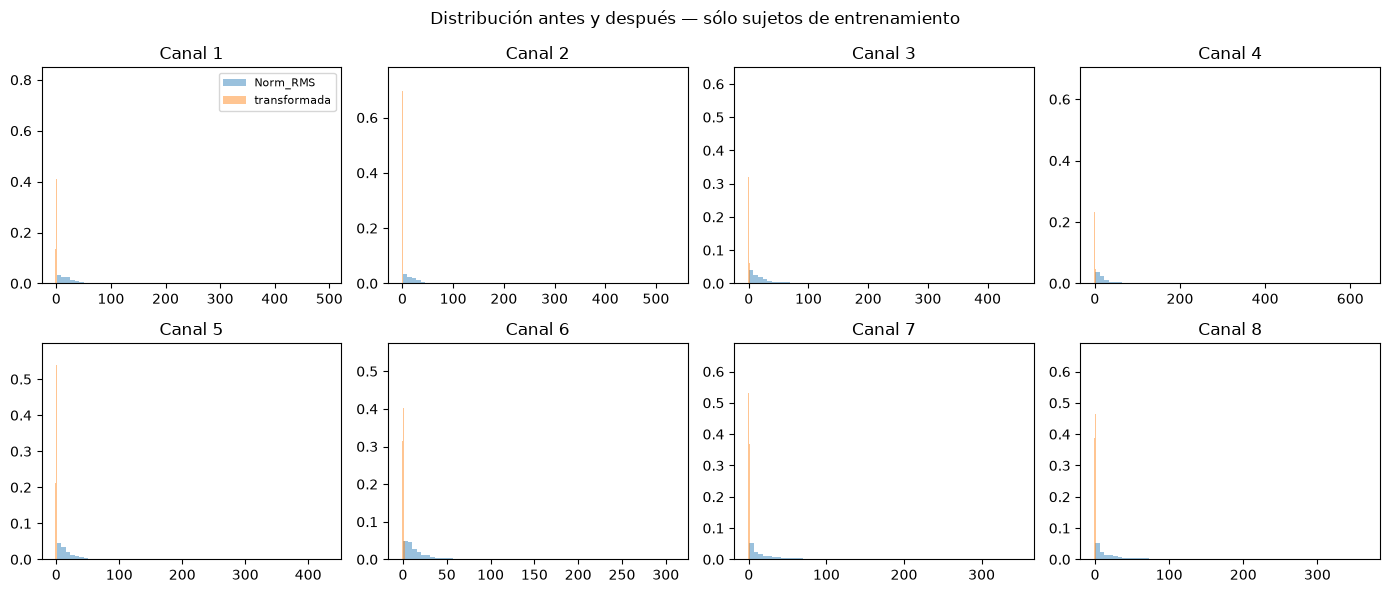

In [7]:
def distribution_diagnostics(raw_windows, transformed_windows, max_points=5_000):
    rows = []
    local_rng = np.random.default_rng(SEED)
    for channel_idx, channel in enumerate(CHANNELS):
        raw = raw_windows[:, channel_idx, :].ravel()
        transformed = transformed_windows[:, channel_idx, :].ravel()
        if len(raw) > max_points:
            index = local_rng.choice(len(raw), max_points, replace=False)
            raw = raw[index]
            transformed = transformed[index]
        for stage, values in [('raw', raw), ('log1p_robust', transformed)]:
            stat, p_value = normaltest(values) if len(values) >= 20 else (np.nan, np.nan)
            rows.append({
                'channel': channel, 'stage': stage,
                'skew': skew(values, bias=False),
                'excess_kurtosis': kurtosis(values, fisher=True, bias=False),
                'normaltest_stat': stat, 'normaltest_p': p_value,
                'median': np.median(values), 'iqr': np.subtract(*np.percentile(values, [75, 25])),
            })
    return pd.DataFrame(rows)

diagnostics = distribution_diagnostics(X_windows[train_mask], X_train_seq)
display(diagnostics.round(4))

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for channel_idx, ax in enumerate(axes.ravel()):
    raw = X_windows[train_mask, channel_idx, :].ravel()
    transformed = X_train_seq[:, channel_idx, :].ravel()
    ax.hist(raw, bins=60, density=True, alpha=0.45, label='Norm_RMS')
    ax.hist(transformed, bins=60, density=True, alpha=0.45, label='transformada')
    ax.set_title(f'Canal {channel_idx + 1}')
    if channel_idx == 0:
        ax.legend(fontsize=8)
fig.suptitle('Distribución antes y después — sólo sujetos de entrenamiento')
fig.tight_layout()

# 3. Selección y extracción de características

## 3.1 Evidencia estadística sin pseudorreplicación

Las ventanas de un mismo sujeto y ensayo están correlacionadas. Tratar cada ventana como observación independiente produciría p-valores artificialmente pequeños. Como diagnóstico de filtro, se resume cada característica por la mediana de cada combinación `sujeto × clase` y se aplica Kruskal–Wallis entre clases. Se controla la tasa de falsos descubrimientos con Benjamini–Hochberg y se reporta $\epsilon^2$ como tamaño de efecto aproximado.

Este análisis no sustituye la validación predictiva por sujeto. Sirve para detectar variables sin señal aparente y para sustentar decisiones, no para declarar causalidad.

In [8]:
def benjamini_hochberg(p_values: np.ndarray) -> np.ndarray:
    p = np.asarray(p_values, dtype=float)
    order = np.argsort(p)
    ranked = p[order]
    adjusted_ranked = np.minimum.accumulate((ranked * len(p) / np.arange(1, len(p) + 1))[::-1])[::-1]
    adjusted = np.empty_like(adjusted_ranked)
    adjusted[order] = np.clip(adjusted_ranked, 0.0, 1.0)
    return adjusted

def grouped_kruskal_table(train_frame: pd.DataFrame, feature_columns: list[str]) -> pd.DataFrame:
    aggregated = (
        train_frame.groupby(['subject', TARGET_COLUMN], as_index=False)[feature_columns].median()
    )
    rows = []
    for feature in feature_columns:
        samples = [
            group[feature].dropna().to_numpy()
            for _, group in aggregated.groupby(TARGET_COLUMN)
            if group[feature].notna().sum() >= 2
        ]
        if len(samples) < 2 or sum(map(len, samples)) <= len(samples):
            rows.append({'feature': feature, 'H': np.nan, 'p_value': np.nan, 'epsilon2': np.nan})
            continue
        try:
            H, p_value = kruskal(*samples)
        except ValueError:  # SciPy falla cuando todos los valores son idénticos.
            H, p_value = 0.0, 1.0
        n_total, n_groups = sum(map(len, samples)), len(samples)
        epsilon2 = max(0.0, (H - n_groups + 1) / (n_total - n_groups))
        rows.append({'feature': feature, 'H': H, 'p_value': p_value, 'epsilon2': epsilon2})
    result = pd.DataFrame(rows)
    valid = result['p_value'].notna()
    result['p_fdr'] = np.nan
    result.loc[valid, 'p_fdr'] = benjamini_hochberg(result.loc[valid, 'p_value'].to_numpy())
    return result.sort_values(['p_fdr', 'epsilon2'], ascending=[True, False])

train_feature_table = feature_table.loc[feature_table['split'].eq('train')].copy()
filter_evidence = grouped_kruskal_table(train_feature_table, NUMERIC_FEATURE_COLUMNS)
display(filter_evidence.head(30).round(5))
print('Características con FDR < 0.05:', int(filter_evidence['p_fdr'].lt(0.05).sum()))

,feature,H,p_value,epsilon2,p_fdr
25,ch2_iqr,36.66355,0.00000,0.78624,0.00023
29,ch2_range,35.61536,0.00000,0.75937,0.00023
21,ch2_std,35.45597,0.00000,0.75528,0.00023
26,ch2_mad,34.58665,0.00001,0.73299,0.00025
65,ch4_iqr,32.90839,0.00001,0.68996,0.00042
45,ch3_iqr,32.09904,0.00002,0.66921,0.00043
6,ch1_mad,31.52883,0.00002,0.65459,0.00043
5,ch1_iqr,31.49741,0.00002,0.65378,0.00043
46,ch3_mad,31.36075,0.00002,0.65028,0.00043
66,ch4_mad,31.17444,0.00002,0.64550,0.00043


Características con FDR < 0.05: 180


## 3.2 Pipeline de filtrado y selección supervisada

El orden importa:

1. `SimpleImputer` es una defensa operacional; el EDA no anticipa nulos.
2. `VarianceThreshold` elimina constantes.
3. El filtro de Spearman conserva una variable por grupo con $|\rho|>0.95$, reduciendo redundancia entre cuantiles, media, RMS y área.
4. `RobustScaler` homogeneiza escalas.
5. `SelectPercentile(mutual_info_classif)` conserva relaciones potencialmente no lineales con la clase.
6. Regresión logística balanceada ofrece una línea base interpretable.

Todos los pasos viven dentro de `Pipeline`; por tanto, se ajustan de nuevo en cada fold y nunca observan el fold de validación.

In [10]:
class SpearmanCorrelationPruner(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95):
        self.threshold = threshold

    def fit(self, X, y=None):
        values = np.asarray(X, dtype=float)
        corr = pd.DataFrame(values).corr(method='spearman').abs().fillna(0.0)
        upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
        self.keep_indices_ = np.array([i for i in range(values.shape[1]) if not (upper.iloc[:, i] > self.threshold).any()])
        self.n_features_in_ = values.shape[1]
        return self

    def transform(self, X):
        values = np.asarray(X, dtype=float)
        return values[:, self.keep_indices_]

    def get_feature_names_out(self, input_features=None):
        names = np.asarray(input_features if input_features is not None else np.arange(self.n_features_in_), dtype=object)
        return names[self.keep_indices_]

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('variance', VarianceThreshold(threshold=0.0)),
    ('correlation', SpearmanCorrelationPruner(threshold=0.95)),
    ('scale', RobustScaler(quantile_range=(25.0, 75.0))),
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# Escenario primario: sólo información derivada de la señal.
signal_only_preprocessor = ColumnTransformer(
    transformers=[('signal', numeric_pipeline, NUMERIC_FEATURE_COLUMNS)],
    remainder='drop',
    verbose_feature_names_out=False,
)

# Sensibilidad: contexto experimental explícito; nunca incluye sujeto, archivo o tiempo.
context_preprocessor = ColumnTransformer(
    transformers=[
        ('signal', numeric_pipeline, NUMERIC_FEATURE_COLUMNS),
        ('categorical', categorical_pipeline, ['task', 'side', 'condition_family']),
        ('load', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scale', RobustScaler())]), ['load_kg']),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

mi_score = partial(mutual_info_classif, random_state=SEED)

def make_selected_classifier(preprocessor: ColumnTransformer) -> Pipeline:
    return Pipeline([
        ('preprocess', preprocessor),
        ('select', SelectPercentile(score_func=mi_score, percentile=50)),
        ('classifier', LogisticRegression(
            max_iter=3_000, class_weight='balanced', solver='lbfgs', random_state=SEED
        )),
    ])

signal_only_model = make_selected_classifier(signal_only_preprocessor)
context_sensitivity_model = make_selected_classifier(context_preprocessor)

In [11]:
# Evaluación interna: sólo sujetos de entrenamiento; los sujetos 11–14 permanecen fuera.
X_development = feature_table.loc[feature_table['split'].eq('train')].copy()
y_development = X_development.pop(TARGET_COLUMN).to_numpy(dtype=np.int64)
development_groups = X_development['subject'].to_numpy(dtype=np.int64)

group_cv = GroupKFold(n_splits=5)
scoring = {
    'f1_macro': make_scorer(f1_score, average='macro', zero_division=0),
    'balanced_accuracy': make_scorer(balanced_accuracy_score),
}

candidate_models = {
    'signal_only': signal_only_model,
    'signal_plus_context_sensitivity': context_sensitivity_model,
}
cv_rows = []
for name, estimator in candidate_models.items():
    scores = cross_validate(
        estimator, X_development, y_development,
        groups=development_groups, cv=group_cv, scoring=scoring, n_jobs=-1,
        return_train_score=False, error_score='raise',
    )
    cv_rows.append({
        'candidate': name,
        'f1_macro_mean': scores['test_f1_macro'].mean(),
        'f1_macro_std': scores['test_f1_macro'].std(ddof=1),
        'balanced_accuracy_mean': scores['test_balanced_accuracy'].mean(),
    })
cv_results = pd.DataFrame(cv_rows).sort_values('f1_macro_mean', ascending=False)
display(cv_results.round(4))

# Regla de decisión recomendada: conservar señal-only como modelo oficial.
# El escenario con contexto sólo cuantifica cuánto depende el resultado del protocolo.

,candidate,f1_macro_mean,f1_macro_std,balanced_accuracy_mean
1,signal_plus_context_sensitivity,0.3233,0.0803,0.4823
0,signal_only,0.2706,0.0624,0.4386


## 3.3 Extracción con PCA: rama opcional, no transformación obligatoria

PCA es útil cuando el objetivo prioritario es reducir tiempo y memoria, pero sacrifica interpretabilidad porque cada componente mezcla canales y familias de características. No se aplica PCA a la serie temporal antes del CPC–xLSTM: destruiría la estructura por canal y complicaría el uso de convoluciones.

La rama siguiente se limita a las características numéricas tabulares, estandariza y conserva 95 % de la varianza. Debe compararse con selección por información mutua usando exactamente los mismos folds agrupados. Se adopta sólo si mantiene F1 macro dentro del margen definido y reduce de forma material el número de dimensiones o el tiempo de ajuste.

In [12]:
pca_model = Pipeline([
    ('columns', ColumnTransformer([
        ('signal', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('variance', VarianceThreshold(threshold=0.0)),
            ('scale', StandardScaler()),
        ]), NUMERIC_FEATURE_COLUMNS),
    ], remainder='drop', verbose_feature_names_out=False)),
    ('pca', PCA(n_components=0.95, svd_solver='full', random_state=SEED)),
    ('classifier', LogisticRegression(
        max_iter=3_000, class_weight='balanced', solver='lbfgs', random_state=SEED
    )),
])

pca_scores = cross_validate(
    pca_model, X_development, y_development,
    groups=development_groups, cv=group_cv, scoring=scoring, n_jobs=-1,
    return_train_score=False, error_score='raise',
)
display(pd.DataFrame([{
    'candidate': 'PCA_95pct_signal_only',
    'f1_macro_mean': pca_scores['test_f1_macro'].mean(),
    'f1_macro_std': pca_scores['test_f1_macro'].std(ddof=1),
    'balanced_accuracy_mean': pca_scores['test_balanced_accuracy'].mean(),
}]).round(4))

# Después de elegir con train-CV, ajustar una sola vez en train y evaluar primero en validation.
X_train_tab = feature_table.loc[feature_table['split'].eq('train')].drop(columns=[TARGET_COLUMN])
y_train_tab = feature_table.loc[feature_table['split'].eq('train'), TARGET_COLUMN].to_numpy()
X_valid_tab = feature_table.loc[feature_table['split'].eq('validation')].drop(columns=[TARGET_COLUMN])
y_valid_tab = feature_table.loc[feature_table['split'].eq('validation'), TARGET_COLUMN].to_numpy()

final_tabular_model = signal_only_model.fit(X_train_tab, y_train_tab)
valid_prediction = final_tabular_model.predict(X_valid_tab)
print('Validation F1 macro:', f1_score(y_valid_tab, valid_prediction, average='macro', zero_division=0))
print('Validation balanced accuracy:', balanced_accuracy_score(y_valid_tab, valid_prediction))

# El test (sujetos 13–14) se abre una sola vez tras congelar todas las decisiones.

,candidate,f1_macro_mean,f1_macro_std,balanced_accuracy_mean
0,PCA_95pct_signal_only,0.2883,0.0682,0.4331


Validation F1 macro: 0.345879119727393
Validation balanced accuracy: 0.4824979262325977


e:\Proyecto_Integrador\human-activity-recognition\.venv\Lib\site-packages\sklearn\metrics\_classification.py:2939: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


# 4. Conclusiones de la preparación de datos — CRISP-ML

## Resultado de la fase

La preparación produce dos vistas coherentes del mismo ensayo: una secuencia `(8, 200)` para CPC–xLSTM y una tabla de características de dominio para líneas base, explicación y posible fusión con la representación aprendida. Ambas conservan identificadores de trazabilidad fuera del espacio predictor.

## Calidad y riesgos residuales

- La ausencia estructural del sujeto 12 no se imputa.
- Los intervalos no anotados no se convierten a `N`; se excluyen de aprendizaje supervisado.
- Las amplitudes superiores a 100 %MVC se conservan como observaciones plausibles y se controlan con transformación robusta.
- La muestra de 14 sujetos limita la precisión de cualquier estimación; deben reportarse dispersión entre folds y métricas por clase.
- La fusión MVNX queda pendiente hasta validar una alineación física por eventos.

## Criterios de salida hacia modelado

Antes de entrenar se deben satisfacer los siguientes controles: (1) cero solapamiento de sujetos entre splits; (2) ventanas supervisadas con cobertura y pureza completas; (3) todas las transformaciones ajustadas sólo en entrenamiento; (4) ausencia de NaN/infinitos; (5) manifiesto versionado de exclusiones; (6) dimensiones, orden de canales, frecuencia y transformación guardados junto al checkpoint.

En términos de CRISP-ML, la fase queda lista para iterar entre preparación, modelado y evaluación. Las decisiones no son irreversibles: sus parámetros (`TARGET_FS`, ventana, pureza, percentil de selección y varianza PCA) deben tratarse como hiperparámetros evaluados por sujeto, no como conclusiones derivadas del conjunto final de prueba.

# 5. Integración con el pipeline CPC–xLSTM

## 5.1 Mapa de integración paso a paso

1. **Catálogo y split:** sustituir `VAL_SUBJECTS={13,14}` por tres conjuntos. Los sujetos 11–12 guían épocas, `K` y arquitectura; 13–14 permanecen cerrados hasta el final.
2. **Resampleo:** conservar `load_resampled`, pero devolver `Norm_RMS` sin z-score por archivo.
3. **Ajuste del preprocesador:** muestrear ventanas exclusivamente de `train_catalog` y ajustar `SequenceLogRobustScaler`.
4. **Dataset CPC:** transformar cada señal con el artefacto ya ajustado; nunca llamar `fit` dentro de `Dataset.__getitem__`. Para CPC no se usan etiquetas y se permiten transiciones.
5. **Causalidad extremo a extremo:** reemplazar el `padding='reflect'` simétrico del encoder por relleno sólo a la izquierda. La prueba actual del xLSTM empieza en `z` y no detecta que el encoder observa hasta tres pasos futuros.
6. **Modelo:** mantener `CPCConfig(n_channels=8)` y la forma `(batch, 8, 200)`. xLSTM, `Predictor` e InfoNCE conservan sus interfaces.
7. **Checkpoint:** guardar cuantiles, centro/escala robusta, frecuencia, ventana, orden de canales y splits junto a los pesos.
8. **Evaluación downstream:** generar sólo ventanas puras; extraer `c_t` del último paso del xLSTM congelado. La línea base `raw_stats` del notebook original no es realmente cruda: opera sobre ventanas ya estandarizadas.
9. **Pipeline sklearn:** concatenar opcionalmente `c_t` con características manuales; ajustar imputación/escalamiento/selección y clasificador sólo con train.
10. **Selección y test:** elegir con train-CV y validation. Reentrenar la configuración congelada con train+validation si así se documenta y evaluar una sola vez en test.

La ingeniería tabular **no** debe insertarse antes del encoder convolucional como sustituto de la serie: CPC necesita la resolución temporal. Su lugar natural es la evaluación downstream o una cabeza híbrida.

## 5.1.1 Corrección de causalidad del encoder

Tres convoluciones de kernel 3 con padding simétrico dan a `z_t` un campo receptivo que alcanza aproximadamente hasta `x_{t+3}`. Como InfoNCE predice horizontes desde `k=1`, el contexto puede observar parte de aquello que debe predecir. El siguiente reemplazo conserva longitud y dimensiones, pero rellena sólo a la izquierda. La verificación perturba la **entrada sEMG**, no el latente, y comprueba todo `Encoder → xLSTM`.

In [13]:
import torch.nn as nn
import torch.nn.functional as F

class CausalEncoder(nn.Module):
    """Misma interfaz del Encoder original, sin acceso a muestras futuras."""

    def __init__(self, cfg):
        super().__init__()
        kernel = cfg.enc_kernel_size
        in_channels = (cfg.n_channels,) + cfg.enc_channels[:-1]
        self.left_pad = kernel - 1
        self.convolutions = nn.ModuleList([
            nn.Conv1d(c_in, c_out, kernel_size=kernel, padding=0)
            for c_in, c_out in zip(in_channels, cfg.enc_channels)
        ])
        self.dropout = nn.Dropout(cfg.enc_dropout)

    def forward(self, x):
        z = x
        for convolution in self.convolutions:
            z = F.pad(z, (self.left_pad, 0))
            z = self.dropout(F.relu(convolution(z)))
        return z

# En CPCModel.__init__ reemplazar: self.encoder = Encoder(cfg)
# por:                           self.encoder = CausalEncoder(cfg)

def assert_end_to_end_causality(model, n_channels=8, length=200, change_at=100, atol=1e-6):
    model.eval()
    x = torch.randn(4, n_channels, length, device=next(model.parameters()).device)
    x_changed = x.clone()
    x_changed[:, :, change_at:] += torch.randn_like(x_changed[:, :, change_at:])
    with torch.no_grad():
        _, context = model.encode(x)
        _, changed_context = model.encode(x_changed)
    past_gap = (context[:, :change_at] - changed_context[:, :change_at]).abs().max().item()
    future_gap = (context[:, change_at:] - changed_context[:, change_at:]).abs().max().item()
    assert past_gap <= atol, f'Fuga temporal: max gap antes de t0 = {past_gap:.3e}'
    assert future_gap > atol, 'La perturbación futura no afectó la salida futura; revisar la prueba.'
    return {'past_gap': past_gap, 'future_gap': future_gap}

# Ejecutar después de construir CPCModel con CausalEncoder:
# assert_end_to_end_causality(model_tmp)

In [14]:
# Adaptación propuesta para la sección 4.1 de 02_Pipeline_CPC_xLSTM.ipynb.
# Reutiliza `model_catalog`, `load_resampled_trial` y `SequenceLogRobustScaler` de este notebook.

from torch.utils.data import Dataset, DataLoader
import torch

train_catalog = model_catalog.loc[model_catalog['split'].eq('train')].copy()
valid_catalog = model_catalog.loc[model_catalog['split'].eq('validation')].copy()
test_catalog = model_catalog.loc[model_catalog['split'].eq('test')].copy()

def sample_cpc_fit_windows(catalog_frame, max_windows_per_trial=4):
    """Muestra reproducible para ajustar el escalador sin cargar todas las ventanas a la vez."""
    sampled = []
    local_rng = np.random.default_rng(SEED)
    for row in catalog_frame.itertuples(index=False):
        signal, _ = load_resampled_trial(row.path)
        last_start = signal.shape[1] - WINDOW_LEN
        if last_start < 0:
            continue
        possible = np.arange(0, last_start + 1, CPC_HOP)
        starts = local_rng.choice(possible, size=min(max_windows_per_trial, len(possible)), replace=False)
        sampled.extend(signal[:, start:start + WINDOW_LEN] for start in starts)
    return np.stack(sampled).astype(np.float32)

cpc_sequence_scaler = SequenceLogRobustScaler()
cpc_sequence_scaler.fit(sample_cpc_fit_windows(train_catalog))

class EMGWindowDatasetV2(Dataset):
    """Dataset CPC sin etiquetas; recibe un preprocesador previamente ajustado."""

    def __init__(self, catalog_frame, preprocessor, window_len=WINDOW_LEN, hop_len=CPC_HOP):
        self.signals = []
        self.index = []
        self.records = []
        for row in catalog_frame.itertuples(index=False):
            raw_signal, _ = load_resampled_trial(row.path)
            if raw_signal.shape[1] < window_len:
                continue
            # El transformador se ajustó antes y sólo con train. Aquí únicamente se aplica.
            signal = preprocessor.transform(raw_signal[None, ...])[0]
            file_index = len(self.signals)
            self.signals.append(torch.from_numpy(signal))
            self.records.append({'file': row.file, 'subject': row.subject})
            for start in range(0, signal.shape[1] - window_len + 1, hop_len):
                self.index.append((file_index, start))
        self.window_len = window_len

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        file_index, start = self.index[idx]
        return self.signals[file_index][:, start:start + self.window_len]

train_ds = EMGWindowDatasetV2(train_catalog, cpc_sequence_scaler)
valid_ds = EMGWindowDatasetV2(valid_catalog, cpc_sequence_scaler)
test_ds = EMGWindowDatasetV2(test_catalog, cpc_sequence_scaler)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
valid_loader = DataLoader(valid_ds, batch_size=64, shuffle=False, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, drop_last=False)

# El resto del CPC conserva el contrato exacto. Dentro del notebook xLSTM:
# cfg = CPCConfig(n_channels=8, n_pred_steps=12, n_anchors=4)

In [15]:
# Guardado reproducible: añadir este bloque al diccionario del checkpoint del xLSTM.
preprocessing_state = {
    'name': 'log1p_winsor_robust_v1',
    'channels': NORM_RMS_COLS,
    'target_fs': TARGET_FS,
    'window_seconds': WINDOW_SECONDS,
    'window_len': WINDOW_LEN,
    'lower_q': cpc_sequence_scaler.lower_q,
    'upper_q': cpc_sequence_scaler.upper_q,
    'lower': cpc_sequence_scaler.lower_.tolist(),
    'upper': cpc_sequence_scaler.upper_.tolist(),
    'center': cpc_sequence_scaler.scaler_.center_.tolist(),
    'scale': cpc_sequence_scaler.scaler_.scale_.tolist(),
    'train_subjects': sorted(TRAIN_SUBJECTS),
    'validation_subjects': sorted(VALID_SUBJECTS),
    'test_subjects': sorted(TEST_SUBJECTS),
    'excluded_files': sorted(bad_signal_files | KNOWN_BAD_LABEL_FILES),
}

def build_checkpoint_payload(model, cfg, history, preprocessing_state):
    """Usar dentro de save_cpc(...); evita depender de variables globales."""
    return {
        'model_state_dict': model.state_dict(),
        'cfg': asdict(cfg),
        'history': history,
        'preprocessing': preprocessing_state,
    }

# checkpoint_payload = build_checkpoint_payload(model, cfg, history, preprocessing_state)
# torch.save(checkpoint_payload, path)

# En inferencia se debe reconstruir exactamente el transformador desde este estado;
# no se recalculan cuantiles, medianas o IQR con el nuevo sujeto.

## 5.2 Integración downstream: `ColumnTransformer` + contexto CPC

El xLSTM congelado produce un contexto `c_t` de 256 dimensiones. Ese vector es una extracción aprendida; puede evaluarse solo o combinarse con las características manuales. Para no favorecer artificialmente al híbrido, se comparan tres representaciones bajo el mismo split y clasificador:

- `CPC context`: sólo `c_t`.
- `Handcrafted`: sólo características de dominio.
- `Hybrid`: concatenación de ambas.

La selección de columnas, escalamiento y `SelectPercentile` se ajustan sólo en train. El contexto experimental se mantiene fuera del análisis principal.

In [ ]:
@torch.no_grad()
def extract_cpc_contexts(model, transformed_windows: np.ndarray, device, batch_size=512) -> np.ndarray:
    model.eval()
    contexts = []
    for start in range(0, len(transformed_windows), batch_size):
        batch = torch.from_numpy(transformed_windows[start:start + batch_size]).to(device)
        _, context_sequence = model.encode(batch)
        contexts.append(context_sequence[:, -1, :].cpu().numpy())
    return np.concatenate(contexts, axis=0)

def build_hybrid_table(model, device, windows, fitted_sequence_scaler, base_feature_table):
    """Aplica el artefacto de train y concatena c_t con las características manuales."""
    transformed = fitted_sequence_scaler.transform(windows)
    cpc_features = extract_cpc_contexts(model, transformed, device=device)
    cpc_columns = [f'cpc_{i:03d}' for i in range(cpc_features.shape[1])]
    table = pd.concat([
        base_feature_table.reset_index(drop=True),
        pd.DataFrame(cpc_features, columns=cpc_columns),
    ], axis=1)
    return table, cpc_columns

def make_hybrid_classifier(cpc_columns):
    hybrid_numeric_columns = NUMERIC_FEATURE_COLUMNS + list(cpc_columns)
    hybrid_preprocessor = ColumnTransformer([
        ('numeric', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('variance', VarianceThreshold()),
            ('correlation', SpearmanCorrelationPruner(threshold=0.95)),
            ('scale', RobustScaler()),
        ]), hybrid_numeric_columns),
    ], remainder='drop', verbose_feature_names_out=False)
    return Pipeline([
        ('preprocess', hybrid_preprocessor),
        ('select', SelectPercentile(score_func=mi_score, percentile=50)),
        ('classifier', LogisticRegression(
            max_iter=3_000, class_weight='balanced', solver='lbfgs', random_state=SEED
        )),
    ])

# Uso dentro del notebook xLSTM, después de seleccionar K con validation:
# hybrid_table, cpc_columns = build_hybrid_table(best_cpc_model, DEVICE, X_windows, sequence_scaler, feature_table)
# hybrid_classifier = make_hybrid_classifier(cpc_columns)
# La comparación final usa F1 macro, balanced accuracy, F1 por clase y matriz de confusión.

## 5.3 Controles finales de integración

Antes de aceptar una corrida CPC–xLSTM:

- Verificar que `cfg.n_channels == 8`, `TARGET_FS == 50` y `WINDOW_LEN == 200`.
- Ejecutar una prueba de causalidad desde la señal de entrada; probar sólo `g_ar` no cubre el encoder.
- Verificar que ninguna identidad de sujeto aparece en más de un split.
- Registrar el hash o versión del manifiesto de exclusiones y del preprocesador.
- Ajustar el preprocesador secuencial sólo con `train_catalog`.
- Usar validation para `K`, número/tipo de bloques xLSTM, épocas y dropout; no consultar test.
- Construir la evaluación supervisada con ventanas puras y conservar la distribución natural de clases en validation/test.
- Evitar, cuando sea viable, que ventanas fuertemente solapadas del mismo ensayo actúen como negativos entre sí en un minibatch CPC; un sampler por archivo reduce falsos negativos.
- Aplicar ponderación de clases sólo al clasificador o sampler de entrenamiento.
- Reportar F1 macro como métrica principal, exactitud balanceada y F1 por clase; la exactitud global es secundaria.
- Comparar CPC preentrenado contra xLSTM aleatorio, características manuales e híbrido con idénticos sujetos.
- Guardar junto al checkpoint toda transformación necesaria para reproducir inferencia.

Con esta integración, la ingeniería de características complementa a CPC en vez de duplicarlo: el xLSTM aprende representación temporal de la señal completa, mientras las características manuales aportan una línea base interpretable y una vista híbrida para comprobar si la representación autosupervisada retiene nivel, dinámica y coactivación relevantes para HAR.